In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

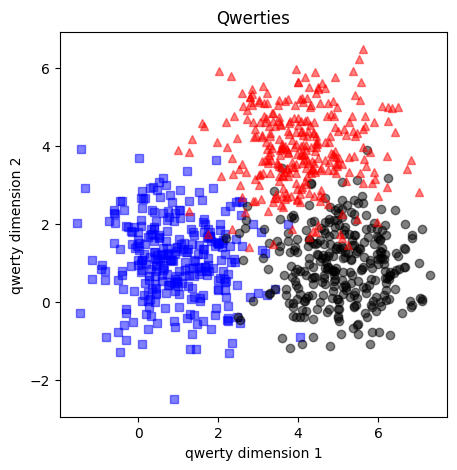

In [2]:
nPerClust = 300
blur = 1

A = [1,1]
B = [5,1]
C = [4,4]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.hstack((
    np.zeros((nPerClust)),
    np.ones((nPerClust)),
    1+np.ones((nPerClust))
))

data_np = np.hstack((a, b, c)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0],0], data[np.where(labels==2)[0],1], 'r^', alpha=.5)
plt.title('Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [3]:
# Separate the data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2)

# Create Tensor Datasets
train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

# Create Data Loaders
batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [7]:
def createTheQwertyNet(initialLR):

    class qwertyNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.input = nn.Linear(2,8)

            self.fc1 = nn.Linear(8,8)

            self.output = nn.Linear(8,3)

        def forward(self, x):
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            return self.output(x)

    net = qwertyNet()

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=initialLR)
    stepsize = batchsize*len(train_loader)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=stepsize, gamma=.5)

    return net, lossfun, optimizer, scheduler

In [8]:
net = createTheQwertyNet(.01)[0]

optimizer = torch.optim.SGD(net.parameters(), lr=.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=1/2)

for epoch in range(3):
    for batchnum in range(10):
        print(f'Batch{batchnum}, epoch {epoch}: LR={scheduler.get_last_lr()[0]}')
        scheduler.step()

Batch0, epoch 0: LR=0.01
Batch1, epoch 0: LR=0.01
Batch2, epoch 0: LR=0.01
Batch3, epoch 0: LR=0.01
Batch4, epoch 0: LR=0.01
Batch5, epoch 0: LR=0.005
Batch6, epoch 0: LR=0.005
Batch7, epoch 0: LR=0.005
Batch8, epoch 0: LR=0.005
Batch9, epoch 0: LR=0.005
Batch0, epoch 1: LR=0.0025
Batch1, epoch 1: LR=0.0025
Batch2, epoch 1: LR=0.0025
Batch3, epoch 1: LR=0.0025
Batch4, epoch 1: LR=0.0025
Batch5, epoch 1: LR=0.00125
Batch6, epoch 1: LR=0.00125
Batch7, epoch 1: LR=0.00125
Batch8, epoch 1: LR=0.00125
Batch9, epoch 1: LR=0.00125
Batch0, epoch 2: LR=0.000625
Batch1, epoch 2: LR=0.000625
Batch2, epoch 2: LR=0.000625
Batch3, epoch 2: LR=0.000625
Batch4, epoch 2: LR=0.000625
Batch5, epoch 2: LR=0.0003125
Batch6, epoch 2: LR=0.0003125
Batch7, epoch 2: LR=0.0003125
Batch8, epoch 2: LR=0.0003125
Batch9, epoch 2: LR=0.0003125


/tmp/ipykernel_11667/1607101272.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [15]:
def function2trainTheModel(initialLR, toggleDynamicLR):

    numepochs = 50

    net, lossfun, optimizer, scheduler = createTheQwertyNet(initialLR)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []
    currentLR = []

    for epochi in range(numepochs):

        # ===== Train =====
        net.train()

        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            # forwardpropagation
            yHat = net(X)
            loss = lossfun(yHat, y)
    
            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            if toggleDynamicLR:
                scheduler.step()
    
            batchLoss.append(loss.item())
    
            matches = torch.argmax(yHat, axis=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100*torch.mean(matchesNumeric)
            batchAcc.append( accuracyPct )
    
            currentLR.append( scheduler.get_last_lr()[0] )

        trainAcc.append( np.mean(batchAcc) )
    
        losses[epochi] = np.mean(batchLoss)
    
        # ===== Eval =====
        net.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = net(X)

        testAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1)==y).float()) )

    return trainAcc, testAcc, losses, net, currentLR

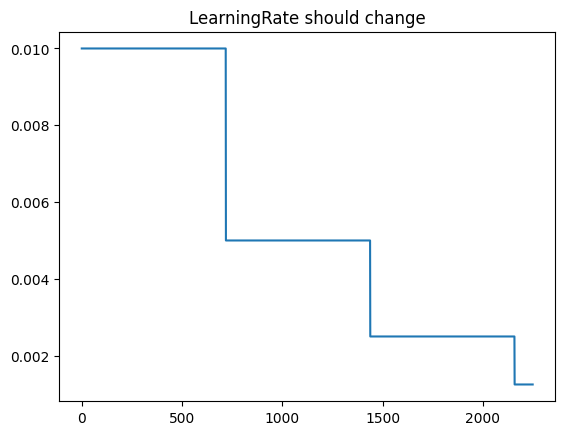

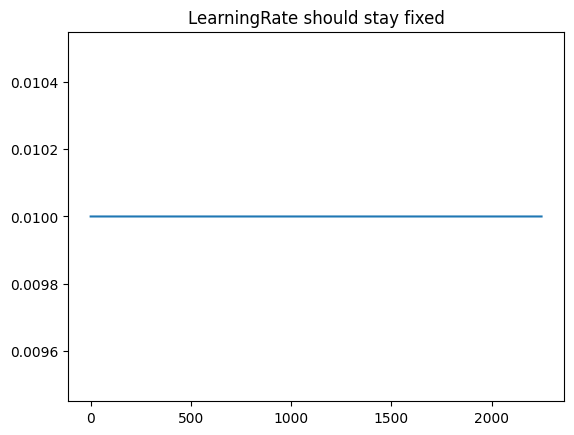

In [17]:
trainAcc, testAcc, losses, net, currentLR = function2trainTheModel(.01, True)
plt.plot(currentLR)
plt.title('LearningRate should change')
plt.show()

trainAcc, testAcc, losses, net, currentLR = function2trainTheModel(.01, False)
plt.plot(currentLR)
plt.title('LearningRate should stay fixed')
plt.show()

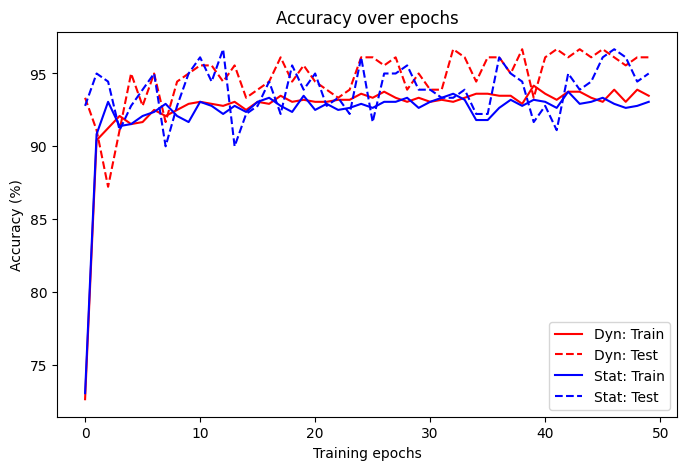

In [19]:
trainAccDynamic, testAccDynamic, losses, net, currentLR = function2trainTheModel(0.1, True)
trainAccStatic, testAccStatic, losses, net, currentLR = function2trainTheModel(0.1, False)

fig = plt.figure(figsize=(8,5))
plt.plot(trainAccDynamic, 'r', label='Dyn: Train')
plt.plot(testAccDynamic, 'r--', label='Dyn: Test')

plt.plot(trainAccStatic, 'b', label='Stat: Train')
plt.plot(testAccStatic, 'b--', label='Stat: Test')

plt.xlabel('Training epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()